<h1 style="text-align:center; font-size:42px; margin-top:40px;">
Web Scraping – Extraction de Salaires par Langage de Programmation
</h1>



## 1. Contexte et objectif

Dans ce module, je mets en place un flux de **web scraping** pour extraire des données structurées depuis une page HTML statique.  
L’objectif est d’automatiser la récupération d’un tableau indiquant les salaires moyens par langage de programmation, puis de produire un fichier CSV exploitable dans le rapport final.

Les informations extraites :
- Langage de programmation  
- Salaire annuel moyen  

Les données collectées sont ensuite nettoyées, converties en valeurs numériques et sauvegardées dans un fichier CSV pour intégration dans la section "tendances salariales" du rapport final.


## 2. Source des données

Les informations proviennent d’une page HTML accessible publiquement contenant un tableau statique de salaires par langage.  
L’URL cible est consultable directement et se prête à un scraping simple :



In [3]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/datasets/Programming_Languages.html"

## 3. Import des librairies nécessaires


In [4]:
from bs4 import BeautifulSoup
import requests
import pandas as pd

## 4. Téléchargement de la page web


In [5]:
res=requests.get(url).content
print(res)

b'<!doctype html>\n<html lang="en">\n<head>\n<title>\nSalary survey results of programming languages\n</title>\n<style>\ntable, th, td {\n  border: 1px solid black;\n}\n</style>\n</head>\n\n<body>\n<hr />\n<h2>Popular Programming Languages</h2>\n<hr />\n<p>Finding out which is the best language is a tough task. A programming language is created to solve a specific problem. A language which is good for task A may not be able to properly handle task B. Comparing programming language is never easy. What we can do, however, is find which is popular in the industry.</p>\n<p>There are many ways to find the popularity of a programming languages. Counting the number of google searchs for each language is a simple way to find the popularity. GitHub and StackOverflow also can give some good pointers.</p>\n<p>Salary surveys are a way to find out the programmings languages that are most in demand in the industry. Below table is the result of one such survey. When using any survey keep in mind that

## 5. Parsing HTML et extraction du tableau

In [6]:
soup=BeautifulSoup(res,"html.parser")

df=pd.DataFrame(columns=["langage","salaire"])
table=soup.find("table")
rows=table.find_all("tr")
i=0
while i<len(rows):
    if i==0: 
        i+=1
        continue
    cols=rows[i].find_all("td")
    langage=cols[1].getText()
    salaire=cols[3].getText()
    dt=pd.DataFrame({"langage":[langage],"salaire":[salaire]})
    df=pd.concat([df,dt],axis=0,ignore_index=True)
    i+=1
df


,langage,salaire
0,Python,"$114,383"
1,Java,"$101,013"
2,R,"$92,037"
3,Javascript,"$110,981"
4,Swift,"$130,801"
5,C++,"$113,865"
6,C#,"$88,726"
7,PHP,"$84,727"
8,SQL,"$84,793"
9,Go,"$94,082"


## 6. Nettoyage et conversion des salaires

In [7]:
df["salaire"] = (
    df["salaire"]
    .str.replace("$", "", regex=False)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

df


,langage,salaire
0,Python,114.383
1,Java,101.013
2,R,92.037
3,Javascript,110.981
4,Swift,130.801
5,C++,113.865
6,C#,88.726
7,PHP,84.727
8,SQL,84.793
9,Go,94.082


## 7. Export CSV

In [8]:
df.to_csv("../Data/External/WebScraping/popular-languages.csv",index=None)

## 8. Visualisation des salaires

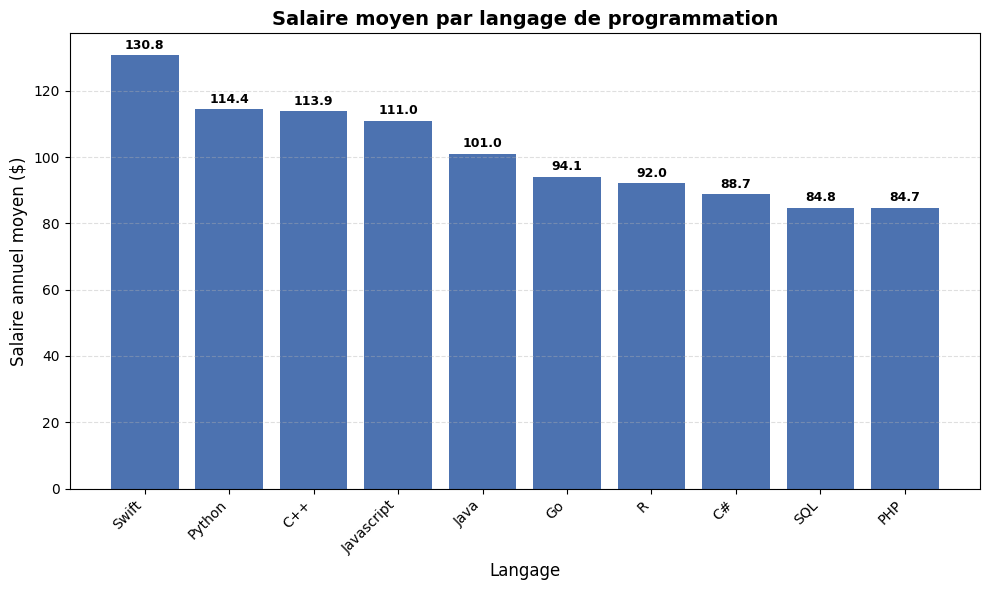

In [14]:
df_plot = df.sort_values("salaire", ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(df_plot["langage"], df_plot["salaire"], color="#4C72B0")

plt.title("Salaire moyen par langage de programmation", fontsize=14, fontweight="bold")
plt.xlabel("Langage", fontsize=12)
plt.ylabel("Salaire annuel moyen ($)", fontsize=12)
plt.xticks(rotation=45, ha="right")

# Ajout des valeurs sur les barres
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        yval + 1,
        f"{yval:.1f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

# Ajout d'une grille légère
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("../Reports/Figures/WebScraping/02_salary_by_language.png")
plt.show()


## 9. Résultat

- Les données extraites sont sauvegardées dans `popular-languages.csv`.
- Le notebook produit un graphique clair mettant en évidence les langages les mieux rémunérés.
- Ces données serviront directement de support visuel dans le rapport final, sans repasser par d'autres notebooks.
